In [2]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import LinearNDInterpolator
from matplotlib import rcParams
rcParams['text.usetex'] = True
rcParams["font.family"] = "Times New Roman"
import matplotlib.pyplot as plt
import math as mth
from IPython.display import display, Math

Pressure points: [2.53423166e-15 6.31228076e-10 2.11053544e-09 3.45078640e-07
 3.79305113e-05 4.74798363e-05 1.73375828e-04 8.80412603e-04]
Rest Mass Density in Geometric Unit: [1.80395910e-11 2.80615860e-07 1.95243310e-06 8.35339027e-05
 3.84987352e-04 7.42370000e-04 8.69391629e-04 1.16207164e-03]
Values of K: [265.86990727912604, 0.1716437570024778, 7.532990936174701e-06, 0.11792993104977989, 1206632.1900944654, 0.0005580312802945671, 2.1748125198895887e+21, 23954218430750.566, 0.01313993117819414]
Values of Gamma: [1.58425    1.28733    0.62223    1.35692    3.07583    0.34196853
 8.2        5.6        0.4       ]
Values of A: [0, -0.0002484731031396745, 0.013534807667054633, 0.0076447131154282425, 0.017228690383717625, 0.21441660324735984, 0.10833907246356873, 0.09268396278228921, 1.5200902703917603]


/tmp/ipykernel_19567/3303695386.py:57: RuntimeWarning: invalid value encountered in scalar power
  return (Pressure/K[0])**(1/Gamma_array[0])


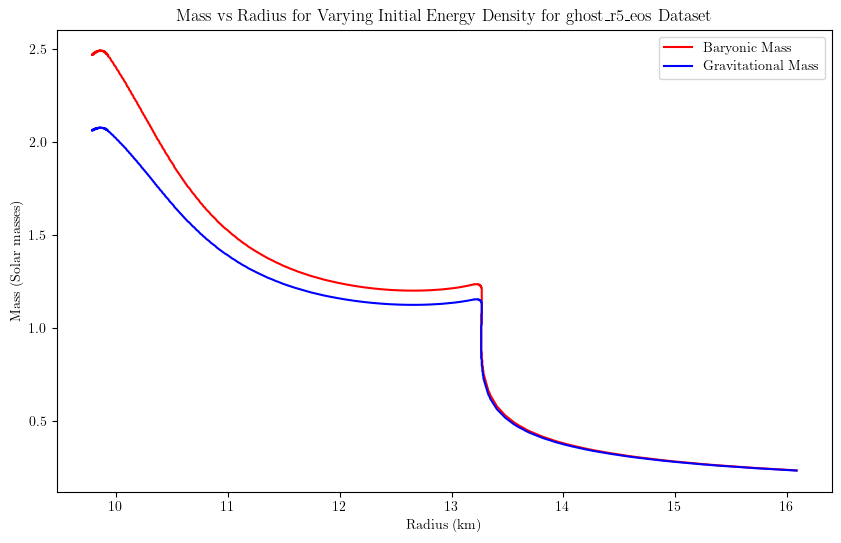

In [40]:
file_path = 'ghost_r5_eos.d'
Gamma_array = np.loadtxt(file_path, skiprows = 2, usecols = 0, max_rows = 9)
K0 = 6.8011 *10 **(-9)
LogRho = np.loadtxt(file_path, skiprows = 14, usecols = 0, max_rows = 8)
Rho_array = np.array([10**i for i in LogRho])  #in g cm-3


K = [K0] # K for cgs outputs
for i in range(1,len(Rho_array)+1):
    Ki = K[i-1]*((Rho_array[i-1])**(Gamma_array[i-1]-Gamma_array[i]))
    K.append(Ki)
    
for i in range(0,len(K)):
    K[i] *= (7.4237e-19)**(1-Gamma_array[i]) #for geometric outputs
    
Rho_array = Rho_array*(7.4237e-19) #in km-2

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def Pressure_function(Rho): #in km-2
    for i in range(len(Rho_array) - 1): 
        if Rho>0 and Rho<=Rho_array[0]:
            return K[0] * (Rho ** Gamma_array[0])
        elif Rho_array[i] < Rho <= Rho_array[i + 1]:
            return K[i+1] * (Rho ** Gamma_array[i+1])
        elif Rho > Rho_array[-1]:
            return K[-1] * (Rho ** Gamma_array[-1])

Pressure_array = np.array([Pressure_function(i) for i in Rho_array])

def Rho_function(Pressure): #in km-2
    for i in range(len(Pressure_array)-1):
        if Pressure <=Pressure_array[0]:
            return (Pressure/K[0])**(1/Gamma_array[0])        
        elif Pressure_array[i] < Pressure <=Pressure_array[i+1]:
            return (Pressure/K[i+1])**(1/Gamma_array[i+1])
        elif Pressure > Pressure_array[-1]:
            return (Pressure/K[-1])**(1/Gamma_array[-1])
        
A_array = [0] #ai

for i in range(1,len(K)):
    ai = A_array[i-1] + ((Pressure_array[i-1]/Rho_array[i-1])*((1/(Gamma_array[i-1]-1))-(1/(Gamma_array[i]-1))))
    A_array.append(ai)

def Energy_Density_function(Pressure):
    for i in range(len(Pressure_array)-1):
        if Pressure <= Pressure_array[0]:
            return ((1+A_array[0]) * Rho_function(Pressure)+((K[0]*(Rho_function(Pressure)**(Gamma_array[0]))))/(Gamma_array[0]-1))
        elif Pressure_array[i] < Pressure <= Pressure_array[i+1]:
            return ((1+A_array[i+1])*Rho_function(Pressure))+((K[i+1]*(Rho_function(Pressure)**(Gamma_array[i+1])))/(Gamma_array[i+1]-1))
        elif Pressure > Pressure_array[-1]:
            return ((1+A_array[-1])*Rho_function(Pressure))+((K[-1]*(Rho_function(Pressure)**(Gamma_array[-1])))/(Gamma_array[-1]-1))
    

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
           ]

print(f'Pressure points: {Pressure_array}')
print(f'Rest Mass Density in Geometric Unit: {Rho_array}')
print(f'Values of K: {K}')
print(f'Values of Gamma: {Gamma_array}')
print(f'Values of A: {A_array}')

final_masses_ghost2 = []
final_radii_ghost2 = []
final_massb_ghost2 = []


Rho0_ghost2 = np.linspace(0.3, 4, 1000) * 58.68e-5
Pressure0_ghost2 = np.array([Pressure_function(i) for i in Rho0_ghost2])
Epsilon0_ghost2 = np.array([Energy_Density_function(i) for i in Pressure0_ghost2])


for n in Rho0_ghost2:
    
    Rho0 = n
    Pressure0 = Pressure_function(Rho0)
    Epsilon0 = Energy_Density_function(Pressure0)
    Radius0 = 0.1                                         # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)  


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_ghost2.append(MassB[-1] / Solar_mass_in_km)
    final_masses_ghost2.append(Mass[-1] / Solar_mass_in_km)
    final_radii_ghost2.append(Radius[-1])

unique_final_masses = set(final_masses_ghost2)
duplicate_mass_cases = [(m, r) for i, m in enumerate(final_masses_ghost2) for j, r in enumerate(final_radii_ghost2) if m == final_masses_ghost2[j] and i != j]

results = []
for mass, radius in duplicate_mass_cases:
    index = final_masses_ghost2.index(mass)
    results.append((mass, radius, Epsilon0_ghost2[index], Pressure0_ghost2[index], Rho0_ghost2[index]))

for result in results:
    print(f"Mass: {result[0]}, Radius: {result[1]}, Epsilon0: {result[2]}, Pressure0: {result[3]}, Rho0: {result[4]}")

plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost2, final_massb_ghost2, 'r-', label='Baryonic Mass')
plt.plot(final_radii_ghost2, final_masses_ghost2, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_r5_eos Dataset')
plt.legend()
plt.show()

Intersection Points:
Radius = 13.27 km, Mass = 1.13 Solar masses
Radius = 12.96 km, Mass = 1.13 Solar masses
Radius = 12.34 km, Mass = 1.13 Solar masses


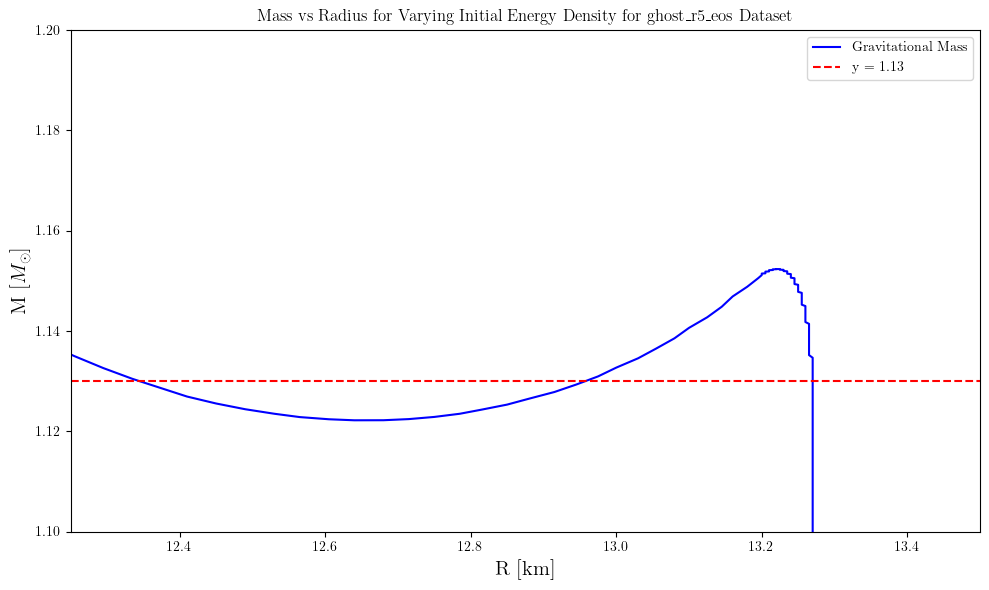

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost2, final_masses_ghost2, 'b-', label='Gravitational Mass')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_r5_eos Dataset')
plt.legend()
plt.xlim(12.25, 13.5)  # Set x-axis limits to zoom around Radius=13
plt.ylim(1.10, 1.20)  # Set y-axis limits to zoom around Mass=1.2

# Add the straight line y=1.13
plt.axhline(y=1.13, color='r', linestyle='--', label='y = 1.13')

# Find intersection points
intersection_points = []
for i in range(len(final_radii_ghost2) - 1):
    x1, x2 = final_radii_ghost2[i], final_radii_ghost2[i + 1]
    y1, y2 = final_masses_ghost2[i], final_masses_ghost2[i + 1]
    
    if (y1 <= 1.13 <= y2) or (y2 <= 1.13 <= y1):
        # Calculate intersection point using linear interpolation
        x_intersect = x1 + (x2 - x1) * (1.13 - y1) / (y2 - y1)
        intersection_points.append((x_intersect, 1.13))

# Print intersection points
print("Intersection Points:")
for point in intersection_points:
    print(f"Radius = {point[0]:.2f} km, Mass = {point[1]:.2f} Solar masses")

plt.tight_layout() 
plt.legend()
# plt.savefig('Twin_r5.pdf', format='pdf',bbox_inches="tight")
plt.show()

Intersection Points:
Radius = 13.270000 km, Mass = 1.130000 Solar masses
Radius = 12.957603 km, Mass = 1.130000 Solar masses
Radius = 12.344572 km, Mass = 1.130000 Solar masses


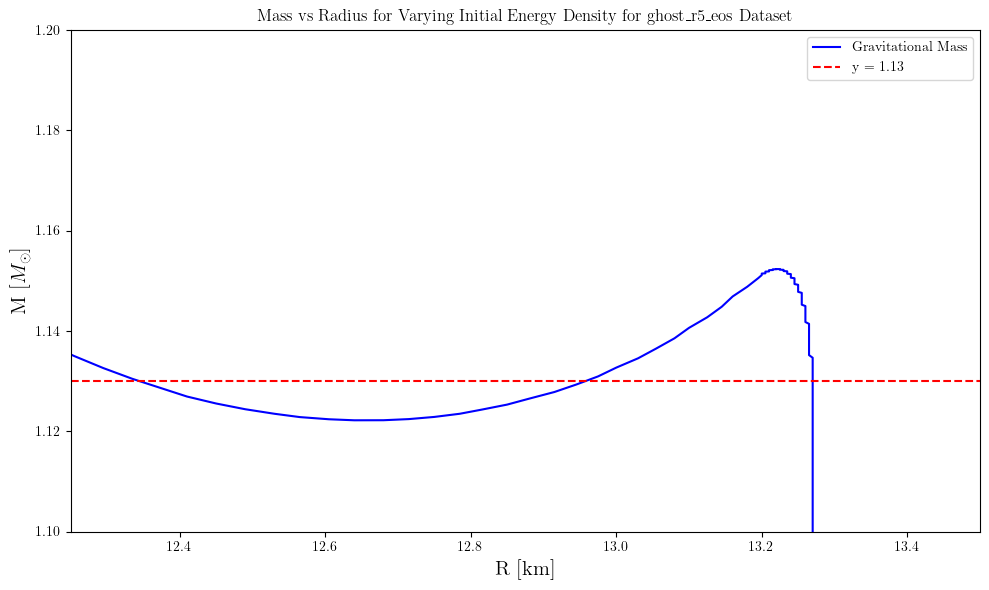

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost2, final_masses_ghost2, 'b-', label='Gravitational Mass')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_r5_eos Dataset')
plt.legend()
plt.xlim(12.25, 13.5)  # Set x-axis limits to zoom around Radius=13
plt.ylim(1.10, 1.20)  # Set y-axis limits to zoom around Mass=1.2

# Add the straight line y=1.13
plt.axhline(y=1.13, color='r', linestyle='--', label='y = 1.13')

# Find intersection points
intersection_points = []
for i in range(len(final_radii_ghost2) - 1):
    x1, x2 = final_radii_ghost2[i], final_radii_ghost2[i + 1]
    y1, y2 = final_masses_ghost2[i], final_masses_ghost2[i + 1]
    
    if (y1 <= 1.13 <= y2) or (y2 <= 1.13 <= y1):
        # Calculate intersection point using linear interpolation
        x_intersect = x1 + (x2 - x1) * (1.13 - y1) / (y2 - y1)
        intersection_points.append((x_intersect, 1.13))

# Round intersection points to precision of 0.000001
intersection_points_rounded = [(round(point[0], 6), round(point[1], 6)) for point in intersection_points]

# Print intersection points
print("Intersection Points:")
for point in intersection_points_rounded:
    print(f"Radius = {point[0]:.6f} km, Mass = {point[1]:.6f} Solar masses")

plt.tight_layout() 
plt.legend()
plt.show()

In [1]:
import numpy as np
from scipy.interpolate import interp1d

# Load the data
filename = 'MR_ghost2_Geometric.d'
data = np.loadtxt(filename, delimiter='\t', skiprows=1)

# Extract the columns
radius = data[:, 5]
rho0 = data[:, 1]

# Create the interpolation function
interpolate_rho0 = interp1d(radius, rho0, kind='linear', fill_value="extrapolate")

# Example usage
radius_value_1 = 12.41
radius_value_2 = 12.95
radius_value_3 = 13.27

# rho0_value = interpolate_rho0(radius_value)

print(f'Rho0 value for radius {radius_value_1} is {interpolate_rho0(radius_value_1)}')
print(f'Rho0 value for radius {radius_value_2} is {interpolate_rho0(radius_value_2)}')
print(f'Rho0 value for radius {radius_value_3} is {interpolate_rho0(radius_value_3)}')

Rho0 value for radius 12.41 is 0.0007997002272727569
Rho0 value for radius 12.95 is 0.0007663842671614661
Rho0 value for radius 13.27 is 0.00037341818183298555


In [2]:
print(f'Rho0 (SI) value for radius {radius_value_1} is {interpolate_rho0(radius_value_1) / (7.4237 * (1e-22))}')
print(f'Rho0 (SI) value for radius {radius_value_2} is {interpolate_rho0(radius_value_2) / (7.4237 * (1e-22))}')
print(f'Rho0 (SI) value for radius {radius_value_3} is {interpolate_rho0(radius_value_3) / (7.4237 * (1e-22))}')
# print(f'Rho0 (CGS) value for radius {radius_value_4} is {interpolate_rho0(radius_value_4) / (7.4237 * (1e-22))}')

Rho0 (SI) value for radius 12.41 is 1.0772259483448372e+18
Rho0 (SI) value for radius 12.95 is 1.0323481109978394e+18
Rho0 (SI) value for radius 13.27 is 5.0300817898485325e+17


Pressure points: [2.53423166e-15 6.31228076e-10 2.11053544e-09 3.26787298e-07
 4.24123567e-06 8.58322532e-05 1.05152232e-04 5.66297250e-04]
Rest Mass Density in Geometric Unit: [1.80395910e-11 2.80615860e-07 1.95243310e-06 8.02474885e-05
 2.18416699e-04 3.99231404e-04 1.10170319e-03 1.88736074e-03]
Values of K: [265.86990727912604, 0.1716437570024778, 7.532990936174701e-06, 0.11792993104977989, 9975.178056183011, 7614538155107.649, 0.00041058735866554124, 187651.92608995023, 1938885.847137698]
Values of Gamma: [1.58425 1.28733 0.62223 1.35692 2.56    4.9865  0.2     3.1277  3.5    ]
Values of A: [0, -0.0002484731031396745, 0.013534807667054633, 0.0076447131154282425, 0.016443701451340706, 0.024020234028379547, 0.34669286123579346, 0.1825280463887744, 0.20352866892863095]


/tmp/ipykernel_19567/3899841601.py:57: RuntimeWarning: invalid value encountered in scalar power
  return (Pressure/K[0])**(1/Gamma_array[0])


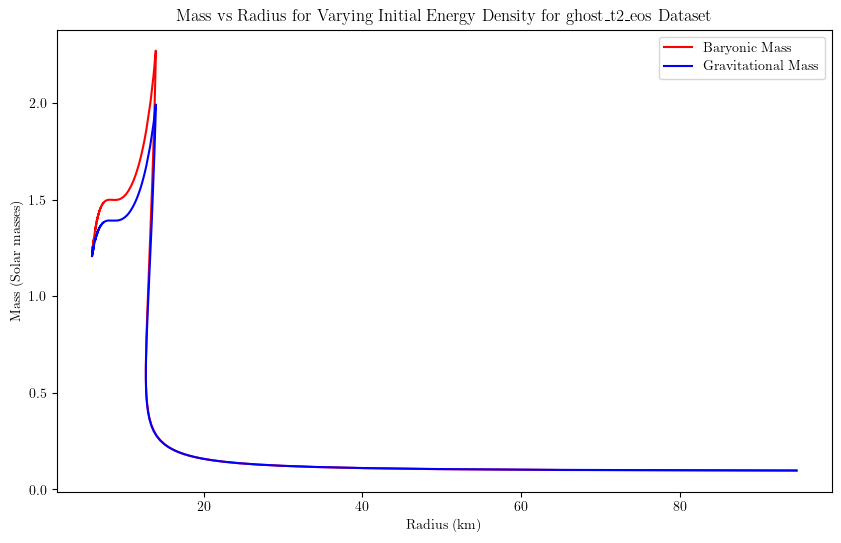

In [44]:
file_path = 'ghost_t2_eos.d'
Gamma_array = np.loadtxt(file_path, skiprows = 2, usecols = 0, max_rows = 9)
K0 = 6.8011 *10 **(-9)
LogRho = np.loadtxt(file_path, skiprows = 14, usecols = 0, max_rows = 8)
Rho_array = np.array([10**i for i in LogRho])  #in g cm-3
Solar_mass_in_km = 1.47662504

K = [K0] 
for i in range(1,len(Rho_array)+1):
    Ki = K[i-1]*((Rho_array[i-1])**(Gamma_array[i-1]-Gamma_array[i]))
    K.append(Ki)
    
for i in range(0,len(K)):
    K[i] *= (7.4237e-19)**(1-Gamma_array[i])
    
Rho_array = Rho_array*(7.4237e-19) 

def dmdr(Epsilon, Radius):
    return 4 * mth.pi * Epsilon * (Radius ** 2)

def dpdr(Epsilon, Pressure, Mass, Radius):
    return (-(Epsilon + Pressure) * (Mass + (4 * mth.pi * (Radius ** 3) * Pressure))) / (Radius * (Radius - (2 * Mass)))

def dMdr(Rho, Mass, Radius):
    return 4 * mth.pi * Rho * (Radius ** 2) * ((1 - 2 * Mass / Radius) ** (-1 / 2))

def Mb0(rho0, m0, r0):
    M = [m0]
    r = r0
    i = 0
    h = 0.005  # Step size
    while r <= r0:
        K_Mass_B_1 = dMdr(rho0, m0, r)
        K_Mass_B_2 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_3 = dMdr(rho0, m0, r + 0.5 * h)
        K_Mass_B_4 = dMdr(rho0, m0, r + h)
        m = M[i] + ((1 / 6) * (K_Mass_B_1 + 2 * K_Mass_B_2 + 2 * K_Mass_B_3 + K_Mass_B_4))
        M.append(m)
        r += h
        i += 1
    return M[-1]

def Pressure_function(Rho): #in km-2
    for i in range(len(Rho_array) - 1): 
        if Rho>0 and Rho<=Rho_array[0]:
            return K[0] * (Rho ** Gamma_array[0])
        elif Rho_array[i] < Rho <= Rho_array[i + 1]:
            return K[i+1] * (Rho ** Gamma_array[i+1])
        elif Rho > Rho_array[-1]:
            return K[-1] * (Rho ** Gamma_array[-1])

Pressure_array = np.array([Pressure_function(i) for i in Rho_array])

def Rho_function(Pressure): #in km-2
    for i in range(len(Pressure_array)-1):
        if Pressure <=Pressure_array[0]:
            return (Pressure/K[0])**(1/Gamma_array[0])        
        elif Pressure_array[i] < Pressure <=Pressure_array[i+1]:
            return (Pressure/K[i+1])**(1/Gamma_array[i+1])
        elif Pressure > Pressure_array[-1]:
            return (Pressure/K[-1])**(1/Gamma_array[-1])
        
A_array = [0] #ai

for i in range(1,len(K)):
    ai = A_array[i-1] + ((Pressure_array[i-1]/Rho_array[i-1])*((1/(Gamma_array[i-1]-1))-(1/(Gamma_array[i]-1))))
    A_array.append(ai)

def Energy_Density_function(Pressure):
    for i in range(len(Pressure_array)-1):
        if Pressure <= Pressure_array[0]:
            return ((1+A_array[0]) * Rho_function(Pressure)+((K[0]*(Rho_function(Pressure)**(Gamma_array[0]))))/(Gamma_array[0]-1))
        elif Pressure_array[i] < Pressure <= Pressure_array[i+1]:
            return ((1+A_array[i+1])*Rho_function(Pressure))+((K[i+1]*(Rho_function(Pressure)**(Gamma_array[i+1])))/(Gamma_array[i+1]-1))
        elif Pressure >= Pressure_array[-1]:
            return ((1+A_array[-1])*Rho_function(Pressure))+((K[-1]*(Rho_function(Pressure)**(Gamma_array[-1])))/(Gamma_array[-1]-1))
    

def RK4_Slope(Mass, MassB, Pressure, Epsilon, Rho, Radius, h):
    k_Mass_1 = dmdr(Epsilon, Radius)
    k_Mass_B_1 = dMdr(Rho, Mass, Radius)
    k_Pressure_1 = dpdr(Epsilon, Pressure, Mass, Radius)
    k_Epsilon_1 = Energy_Density_function(Pressure)
    k_Rho_1 = Rho_function(Pressure)

    k_Mass_2 = dmdr(Epsilon + 0.5 * h * k_Epsilon_1, Radius + 0.5 * h)
    k_Mass_B_2 = dMdr(Rho + 0.5 * h * k_Rho_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Pressure_2 = dpdr(Epsilon + 0.5 * h * k_Epsilon_1, Pressure + 0.5 * h * k_Pressure_1, Mass + 0.5 * h * k_Mass_1, Radius + 0.5 * h)
    k_Epsilon_2 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_1)
    k_Rho_2 = Rho_function(Pressure + 0.5 * h * k_Pressure_1)

    k_Mass_3 = dmdr(Epsilon + 0.5 * h * k_Epsilon_2, Radius + 0.5 * h)
    k_Mass_B_3 = dMdr(Rho + 0.5 * h * k_Rho_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Pressure_3 = dpdr(Epsilon + 0.5 * h * k_Epsilon_2, Pressure + 0.5 * h * k_Pressure_2, Mass + 0.5 * h * k_Mass_2, Radius + 0.5 * h)
    k_Epsilon_3 = Energy_Density_function(Pressure + 0.5 * h * k_Pressure_2)
    k_Rho_3 = Rho_function(Pressure + 0.5 * h * k_Pressure_2)

    k_Mass_4 = dmdr(Epsilon + h * k_Epsilon_3, Radius + h)
    k_Mass_B_4 = dMdr(Rho + h * k_Rho_3, Mass + h * k_Mass_3, Radius + h)
    k_Pressure_4 = dpdr(Epsilon + h * k_Epsilon_3, Pressure + h * k_Pressure_3, Mass + h * k_Mass_3, Radius + h)
    k_Epsilon_4 = Energy_Density_function(Pressure + h * k_Pressure_3)
    k_Rho_4 = Rho_function(Pressure + h * k_Pressure_3)

    return [(1 / 6) * (k_Mass_1 + 2 * k_Mass_2 + 2 * k_Mass_3 + k_Mass_4),
            (1 / 6) * (k_Mass_B_1 + 2 * k_Mass_B_2 + 2 * k_Mass_B_3 + k_Mass_B_4),
            (1 / 6) * (k_Pressure_1 + 2 * k_Pressure_2 + 2 * k_Pressure_3 + k_Pressure_4),
           ]

print(f'Pressure points: {Pressure_array}')
print(f'Rest Mass Density in Geometric Unit: {Rho_array}')
print(f'Values of K: {K}')
print(f'Values of Gamma: {Gamma_array}')
print(f'Values of A: {A_array}')

final_masses_ghost3 = []
final_radii_ghost3 = []
final_massb_ghost3 = []


Rho0_ghost3 = np.linspace(0.2, 10, 1000) * 58.68e-5
Pressure0_ghost3 = np.array([Pressure_function(i) for i in Rho0_ghost3])
Epsilon0_ghost3 = np.array([Energy_Density_function(i) for i in Pressure0_ghost3])


for n in Rho0_ghost3:
    
    Rho0 = n
    Pressure0 = Pressure_function(Rho0)
    Epsilon0 = Energy_Density_function(Pressure0)
    Radius0 = 0.1                                         # Geometric Unit
    Mass0 = (4 / 3) * mth.pi * (Radius0 ** 3) * Epsilon0  # Geometric Unit
    h = 0.005
    Pressure_Limit = 10 ** (-14)
    MassB0 = Mb0(Rho0, Mass0, Radius0)  


    MassB = [MassB0]
    Mass = [Mass0]
    Pressure = [Pressure0]
    Epsilon = [Epsilon0]
    Radius = [Radius0]
    Rho = [Rho0]

    
    while Pressure[-1] > Pressure_Limit:
        Coefficient = RK4_Slope(Mass[-1], MassB[-1], Pressure[-1], Epsilon[-1], Rho[-1], Radius[-1], h)
        Mass_i = Mass[-1] + h * Coefficient[0]
        MassB_i = MassB[-1] + h * Coefficient[1]
        Pressure_i = Pressure[-1] + h * Coefficient[2]
        Epsilon_i = Energy_Density_function(Pressure_i)
        Rho_i = Rho_function(Pressure_i)
        Radius_i = Radius[-1] + h

        MassB.append(MassB_i)
        Mass.append(Mass_i)
        Pressure.append(Pressure_i)
        Epsilon.append(Epsilon_i)
        Radius.append(Radius_i)
        Rho.append(Rho_i)

    final_massb_ghost3.append(MassB[-1] / Solar_mass_in_km)
    final_masses_ghost3.append(Mass[-1] / Solar_mass_in_km)
    final_radii_ghost3.append(Radius[-1])


plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost3, final_massb_ghost3, 'r-', label='Baryonic Mass')
plt.plot(final_radii_ghost3, final_masses_ghost3, 'b-', label='Gravitational Mass')
plt.xlabel('Radius (km)')
plt.ylabel('Mass (Solar masses)')
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_t2_eos Dataset')
plt.legend()
plt.show()

(1.0, 2.0)

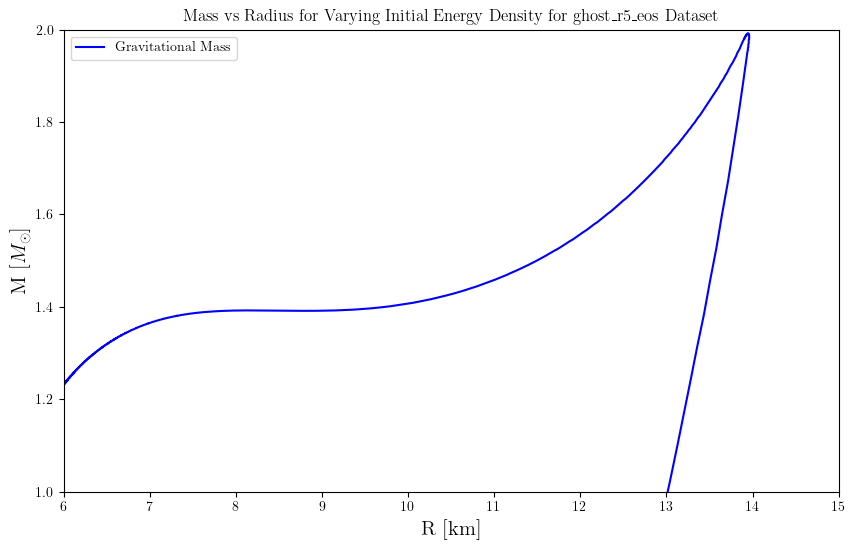

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost3, final_masses_ghost3, 'b-', label='Gravitational Mass')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_t2_eos Dataset')
plt.legend()
plt.xlim(6, 15)  # Set x-axis limits to zoom around Radius=13
plt.ylim(1, 2)  # Set y-axis limits to zoom around Mass=1.2


Intersection Points:
Radius = 13.644875 km, Mass = 1.600000 Solar masses
Radius = 12.306704 km, Mass = 1.600000 Solar masses


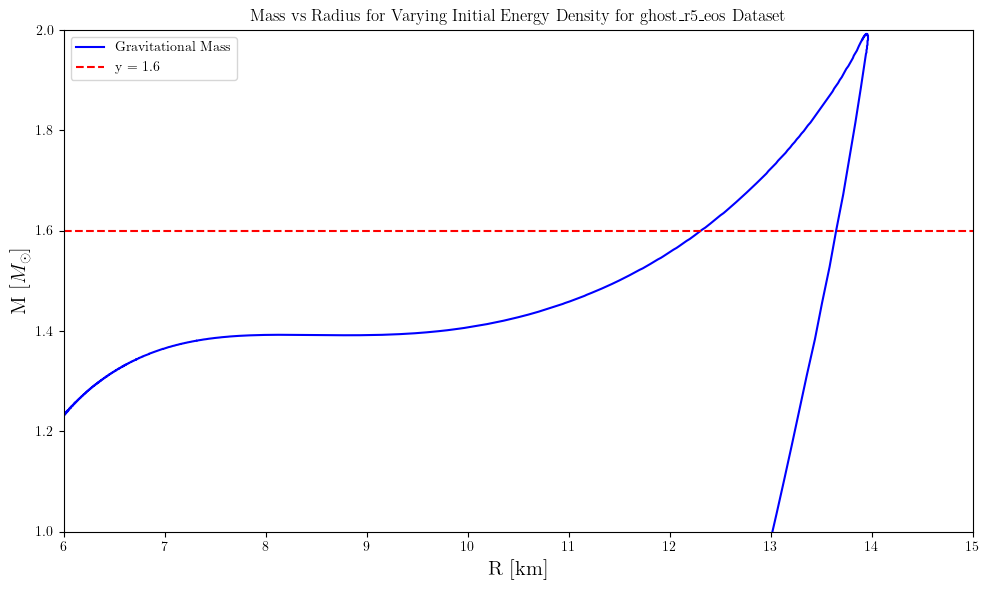

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost3, final_masses_ghost3, 'b-', label='Gravitational Mass')
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_t2_eos Dataset')
plt.legend()
plt.xlim(6, 15)
plt.ylim(1, 2)
plt.axhline(y=1.6, color='r', linestyle='--', label='y = 1.6')


intersection_points = []
for i in range(len(final_radii_ghost3) - 1):
    x1, x2 = final_radii_ghost3[i], final_radii_ghost3[i + 1]
    y1, y2 = final_masses_ghost3[i], final_masses_ghost3[i + 1]
    
    if (y1 <= 1.6 <= y2) or (y2 <= 1.6 <= y1):
        # Calculate intersection point using linear interpolation
        x_intersect = x1 + (x2 - x1) * (1.6 - y1) / (y2 - y1)
        intersection_points.append((x_intersect, 1.6))


intersection_points_rounded = [(round(point[0], 6), round(point[1], 6)) for point in intersection_points]


print("Intersection Points:")
for point in intersection_points_rounded:
    print(f"Radius = {point[0]:.6f} km, Mass = {point[1]:.6f} Solar masses")

plt.tight_layout() 
plt.legend()
plt.show()

Intersection Points:
Radius = 13.443091 km, Mass = 1.392000 Solar masses
Radius = 9.098791 km, Mass = 1.392000 Solar masses
Radius = 8.432194 km, Mass = 1.392000 Solar masses
Radius = 7.972767 km, Mass = 1.392000 Solar masses


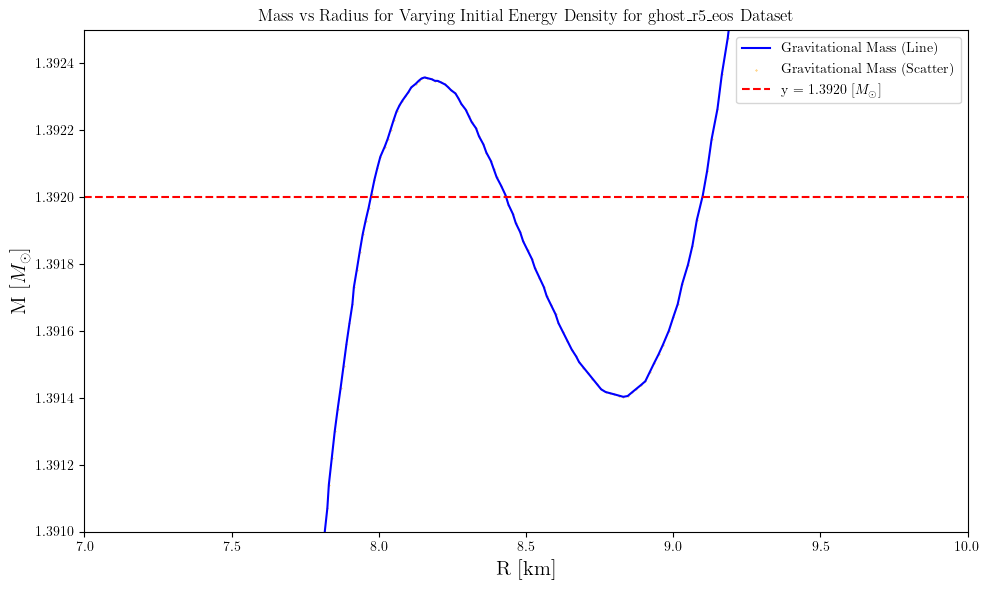

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(final_radii_ghost3, final_masses_ghost3, 'b-', label='Gravitational Mass (Line)')
plt.scatter(final_radii_ghost3, final_masses_ghost3, c='orange', label='Gravitational Mass (Scatter)', s = 0.1)
plt.xlabel('R [km]', fontsize=15)
plt.ylabel('M $[M_{\odot}]$', fontsize=15)
plt.title('Mass vs Radius for Varying Initial Energy Density for ghost_t2_eos Dataset')
plt.legend()
plt.xlim(7, 10) 
plt.ylim(1.3910, 1.3925)  
plt.axhline(y=1.3920, color='r', linestyle='--', label='y = 1.3920 $[M_{\odot}]$')


intersection_points = []
for i in range(len(final_radii_ghost3) - 1):
    x1, x2 = final_radii_ghost3[i], final_radii_ghost3[i + 1]
    y1, y2 = final_masses_ghost3[i], final_masses_ghost3[i + 1]
    
    if (y1 <= 1.3920 <= y2) or (y2 <= 1.3920 <= y1):
        x_intersect = x1 + (x2 - x1) * (1.3920 - y1) / (y2 - y1)
        intersection_points.append((x_intersect, 1.3920))

intersection_points_rounded = [(round(point[0], 6), round(point[1], 6)) for point in intersection_points]


print("Intersection Points:")
for point in intersection_points_rounded:
    print(f"Radius = {point[0]:.6f} km, Mass = {point[1]:.6f} Solar masses")

plt.tight_layout()
plt.legend()
plt.savefig('MR_r5_twinrange.pdf', format='pdf',bbox_inches="tight")
plt.show()

In [4]:
filename = 'MR_ghost2_Geometric.d'
data = np.loadtxt(filename, delimiter='\t', skiprows=1)

# Extract the columns
radius = data[:, 5]
rho0 = data[:, 1]

# Create the interpolation function
interpolate_rho0 = interp1d(radius, rho0, kind='linear', fill_value="extrapolate")

# Example usage
radius_value_1 = 13.443091
radius_value_2 = 9.098791
radius_value_3 = 8.432194
radius_value_4 = 7.972767

# rho0_value = interpolate_rho0(radius_value)

print(f'Rho0 value for radius {radius_value_1} is {interpolate_rho0(radius_value_1)}')
print(f'Rho0 value for radius {radius_value_2} is {interpolate_rho0(radius_value_2)}')
print(f'Rho0 value for radius {radius_value_3} is {interpolate_rho0(radius_value_3)}')
print(f'Rho0 value for radius {radius_value_4} is {interpolate_rho0(radius_value_4)}')

Rho0 value for radius 13.443091 is 0.000260521209167545
Rho0 value for radius 9.098791 is 0.011376712317818456
Rho0 value for radius 8.432194 is 0.020148159242180694
Rho0 value for radius 7.972767 is 0.0261935503047252


In [5]:
print(f'Rho0 (CGS) value for radius {radius_value_1} is {interpolate_rho0(radius_value_1) / (7.4237 * (1e-19))}')
print(f'Rho0 (CGS) value for radius {radius_value_2} is {interpolate_rho0(radius_value_2) / (7.4237 * (1e-19))}')
print(f'Rho0 (CGS) value for radius {radius_value_3} is {interpolate_rho0(radius_value_3) / (7.4237 * (1e-19))}')
print(f'Rho0 (CGS) value for radius {radius_value_4} is {interpolate_rho0(radius_value_4) / (7.4237 * (1e-19))}')

Rho0 (CGS) value for radius 13.443091 is 350931757974520.75
Rho0 (CGS) value for radius 9.098791 is 1.532485461133728e+16
Rho0 (CGS) value for radius 8.432194 is 2.714031984344827e+16
Rho0 (CGS) value for radius 7.972767 is 3.5283686443047536e+16


In [6]:
print(f'Rho0 (SI) value for radius {radius_value_1} is {interpolate_rho0(radius_value_1) / (7.4237 * (1e-22))}')
print(f'Rho0 (SI) value for radius {radius_value_2} is {interpolate_rho0(radius_value_2) / (7.4237 * (1e-22))}')
print(f'Rho0 (SI) value for radius {radius_value_3} is {interpolate_rho0(radius_value_3) / (7.4237 * (1e-22))}')
print(f'Rho0 (SI) value for radius {radius_value_4} is {interpolate_rho0(radius_value_4) / (7.4237 * (1e-22))}')

Rho0 (SI) value for radius 13.443091 is 3.509317579745207e+17
Rho0 (SI) value for radius 9.098791 is 1.5324854611337277e+19
Rho0 (SI) value for radius 8.432194 is 2.714031984344827e+19
Rho0 (SI) value for radius 7.972767 is 3.528368644304753e+19
